# NICAR 2026 geopandas demo

This notebook demonstrates a geospatial analysis of San Francisco 311 graffiti reports and police station locations.

**Data in the `data/` folder:**
- `sf_311_graffiti_2025.csv` — graffiti reports in SF from 2025 (CSV)
- `sf_neighborhoods.zip` — SF neighborhood boundaries (shapefile)
- `sfpd_stations.geojson` — SFPD station locations (geojson)

**Let's take a look at our files!**

## Importing libraries and loading the data

##### Import libraries

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

##### Let's load in our data!

Load in the neighborhoods shapefile with `gpd.read_file()`

In [3]:
neighborhoods = gpd.read_file('../data/sf_neighborhoods.zip')
neighborhoods.head()

,nhood,geometry
0,Western Addition,"POLYGON ((-122.42144 37.78557, -122.42136 37.7..."
1,West of Twin Peaks,"POLYGON ((-122.46104 37.75096, -122.46055 37.7..."
2,Visitacion Valley,"POLYGON ((-122.40385 37.71883, -122.40355 37.7..."
3,Twin Peaks,"POLYGON ((-122.44695 37.75655, -122.44595 37.7..."
4,South of Market,"POLYGON ((-122.40371 37.78404, -122.40271 37.7..."


Load in the police stations geojson with `gpd.read_file()` 

In [4]:
stations = gpd.read_file('../data/sfpd_stations.geojson')
stations.head()

,OBJECTID_1,DISTRICT,COMPANY,DIST,CO,DIST_ORD,ZIP_CODE,PHONE,TIP_LINE,TTY_LINE,PERMIT_OFF,EMAIL,TWITTER,WEB_SITE,STN_ADDRESS,geometry
0,1,CENTRAL,A,CENT,Co. A,A.CENT,94133,1-415-315-2400,1-415-392-2623,1-415-576-1711,1-415-315-2423,SFPDCentralStation@sfgov.org,https://twitter.com/SFPDCentral,https://sanfranciscopolice.org/central,766 VALLEJO ST,POINT (-122.40988 37.79865)
1,2,SOUTHERN,B,SOUT,Co. B,B.SOUT,94158,1-415-575-6000,1-415-552-4901,1-415-575-6079,1-415-575-6000,SFPDSouthernStation@sfgov.org,https://twitter.com/SFPDSouthern,https://sanfranciscopolice.org/southern,1251 3RD ST,POINT (-122.38918 37.77219)
2,3,BAYVIEW,C,BAYV,Co. C,C.BAYV,94124,1-415-671-2300,1-415-822-8147,1-415-671-2346,1-415-671-2313,SFPDBayviewStation@sfgov.org,https://twitter.com/SFPDBayview,https://sanfranciscopolice.org/bayview,201 WILLIAMS AV,POINT (-122.3981 37.72965)
3,4,MISSION,D,MISS,Co. D,D.MISS,94110,1-415-558-5400,1-415-552-4558,1-415-431-6241,1-415-558-5413,SFPDMissionStation@sfgov.org,https://twitter.com/SFPDMission,https://sanfranciscopolice.org/mission,630 VALENCIA ST,POINT (-122.42202 37.763)
4,5,NORTHERN,E,NORT,Co. E,E.NORT,94115,1-415-614-3400,1-415-822-8147,1-415-614-3438,1-415-614-3405,SFPDNorthernStation@sfgov.org,https://twitter.com/SFPDNorthern,https://sanfranciscopolice.org/northern,1125 FILLMORE ST,POINT (-122.4324 37.78017)


Load in the graffiti CSV with `pd.read_csv()`

In [5]:
graffiti_df = pd.read_csv('../data/sf_311_graffiti_2025.csv')

Convert the CSV into a geo dataframe
```
gpd.GeoDataFrame(yourDataFrameName, 
                geometry=gpd.points_from_xy(lng_column, lat_column), 
                crs='EPSG:4326')

```

We're starting with a geographic CRS for now!

In [6]:
graffiti = gpd.GeoDataFrame(
    graffiti_df,
    geometry=gpd.points_from_xy(graffiti_df['Longitude'], graffiti_df['Latitude']),
    crs='EPSG:4326'
)
graffiti.head(2)

,CaseID,Opened,Closed,Updated,Status,Status Notes,Responsible Agency,Category,Request Type,Request Details,...,Supervisor District,Police District,Latitude,Longitude,Point,point_geom,Source,Media URL,BOS_2012,geometry
0,101001244311,01/01/2025 07:31:01 AM,01/11/2025 10:00:08 PM,01/15/2025 10:19:48 PM,Closed,"Case Resolved - Inspected, transfered to SFUSD...",311 - Supervisor,Graffiti Private,not_offensive,building_other,...,8.0,MISSION,37.763681,-122.430664,"(37.76368108549541, -122.43066406972483)",POINT (-122.43066407 37.763681085),Mobile,https://spot-sf-res.cloudinary.com/image/uploa...,NaN,POINT (-122.43066 37.76368)
1,101001244328,01/01/2025 07:39:50 AM,01/11/2025 10:00:08 PM,01/15/2025 10:19:20 PM,Closed,Case Resolved - Closed: No response from DPW B...,PW - Street and Environmental Services,Graffiti Private,not_offensive,building_other,...,8.0,MISSION,37.761403,-122.427989,"(37.761403058228545, -122.42798876864607)",POINT (-122.427988769 37.761403058),Mobile,https://spot-sf-res.cloudinary.com/image/uploa...,NaN,POINT (-122.42799 37.7614)


Make sure everything has the same CRS with `.to_crs()`. 

In [7]:
neighborhoods = neighborhoods.to_crs(graffiti.crs)
stations = stations.to_crs(graffiti.crs)

## Visualizing the data
Let's make a map with layers for neighborhoods, graffiti, and stations!

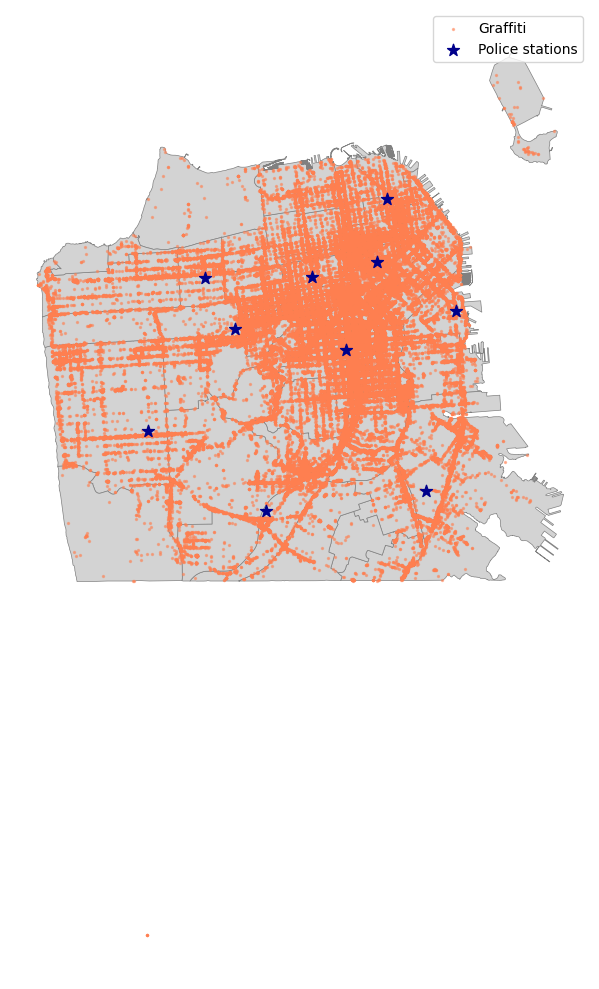

In [8]:
# Define our figure size and axes with `plt.subplots()`
fig, ax = plt.subplots(figsize=(10, 10))

# Plot our neighborhoods with `.plot()`
neighborhoods.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.5)

# Plot our graffiti with `.plot()`
graffiti.plot(ax=ax, color='coral', markersize=2, alpha=0.5, label='Graffiti')

# Plot our stations with `.plot()`
stations.plot(ax=ax, color='darkblue', markersize=80, marker='*', label='Police stations')

# Optional parameters for legend; layout        
ax.legend()
ax.axis('off')
plt.tight_layout()

# Show our map with `plt.show()`!
plt.show()

## Question 1: Which neighborhoods have the most graffiti complaints? 

### Merging neighborhoods data with graffiti data

Let's remind ourselves what our `neighborhoods` data looks like

In [9]:
neighborhoods.head()

,nhood,geometry
0,Western Addition,"POLYGON ((-122.42144 37.78557, -122.42136 37.7..."
1,West of Twin Peaks,"POLYGON ((-122.46104 37.75096, -122.46055 37.7..."
2,Visitacion Valley,"POLYGON ((-122.40385 37.71883, -122.40355 37.7..."
3,Twin Peaks,"POLYGON ((-122.44695 37.75655, -122.44595 37.7..."
4,South of Market,"POLYGON ((-122.40371 37.78404, -122.40271 37.7..."


And then join our neighborhoods data with our complaints data using `gpd.sjoin()` with `within`

In [10]:
graffiti_with_nhood = gpd.sjoin(
    graffiti,
    neighborhoods,
    how='left',
    predicate='within'
)

In [11]:
graffiti_with_nhood.head(1) 
# index_right is the original index of the neighborhoods data

,CaseID,Opened,Closed,Updated,Status,Status Notes,Responsible Agency,Category,Request Type,Request Details,...,Latitude,Longitude,Point,point_geom,Source,Media URL,BOS_2012,geometry,index_right,nhood
0,101001244311,01/01/2025 07:31:01 AM,01/11/2025 10:00:08 PM,01/15/2025 10:19:48 PM,Closed,"Case Resolved - Inspected, transfered to SFUSD...",311 - Supervisor,Graffiti Private,not_offensive,building_other,...,37.763681,-122.430664,"(37.76368108549541, -122.43066406972483)",POINT (-122.43066407 37.763681085),Mobile,https://spot-sf-res.cloudinary.com/image/uploa...,NaN,POINT (-122.43066 37.76368),38.0,Castro/Upper Market


Check if anything didn't get matched using `.isna()`

In [12]:
graffiti_with_nhood[graffiti_with_nhood['nhood'].isna()]
# 706 missing! that's crazy
# but if we look more closely, we can see most of these are missing lat/long - let's filter those out too
not_in_nhood = graffiti_with_nhood[(graffiti_with_nhood['nhood'].isna()) & (graffiti_with_nhood['Latitude'].isna() == False)]


Look at where the missing popints are on a map using `.plot()`

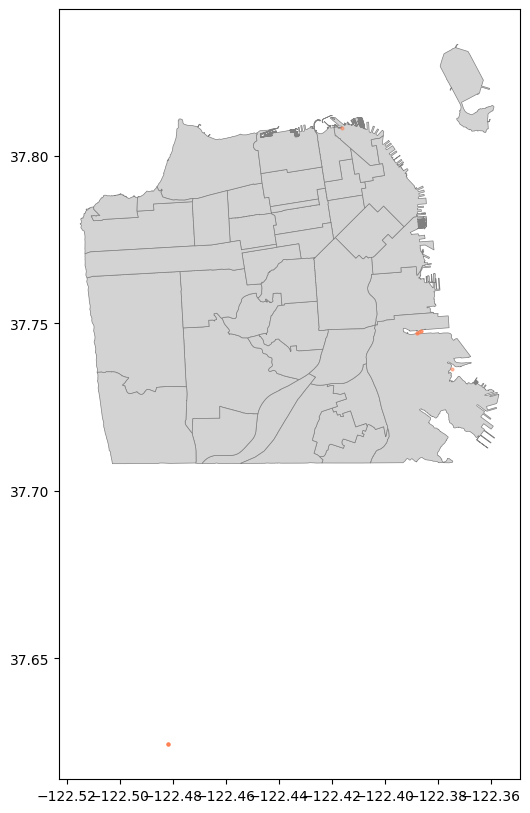

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

neighborhoods.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.5)
not_in_nhood.plot(ax=ax, color='coral', markersize=4, alpha=0.5, label='Graffiti')


plt.show()

# something to be aware of and look into; maybe a different neighborhoods file could help

#### Getting complaints by neighborhood

Use `groupby()` to see counts by neighborhood

In [14]:
# raw counts
graffiti_counts = graffiti_with_nhood.groupby(['nhood']).size().reset_index(name="count")
graffiti_counts.sort_values(by="count",ascending=False).head()
# size includes all values, count excludes missing ones

,nhood,count
18,Mission,36346
8,Haight Ashbury,7906
2,Castro/Upper Market,7295
9,Hayes Valley,6743
33,South of Market,5428


Make a new column for percentages if desired

In [15]:

total = graffiti_counts['count'].sum()
graffiti_counts['pct'] = (graffiti_counts['count'] / total * 100).round(1)

graffiti_counts.sort_values(by="pct",ascending=False).head()

,nhood,count,pct
18,Mission,36346,29.2
8,Haight Ashbury,7906,6.4
2,Castro/Upper Market,7295,5.9
9,Hayes Valley,6743,5.4
33,South of Market,5428,4.4


#### Let's map it!

Merge neighborhood geometries back in with `merge()`

In [16]:
neighborhood_graffiti = neighborhoods.merge(graffiti_counts, on='nhood', how='left')
neighborhood_graffiti.head()

,nhood,geometry,count,pct
0,Western Addition,"POLYGON ((-122.42144 37.78557, -122.42136 37.7...",3479,2.8
1,West of Twin Peaks,"POLYGON ((-122.46104 37.75096, -122.46055 37.7...",3264,2.6
2,Visitacion Valley,"POLYGON ((-122.40385 37.71883, -122.40355 37.7...",425,0.3
3,Twin Peaks,"POLYGON ((-122.44695 37.75655, -122.44595 37.7...",590,0.5
4,South of Market,"POLYGON ((-122.40371 37.78404, -122.40271 37.7...",5428,4.4


Create a choropleth map with `plot()`

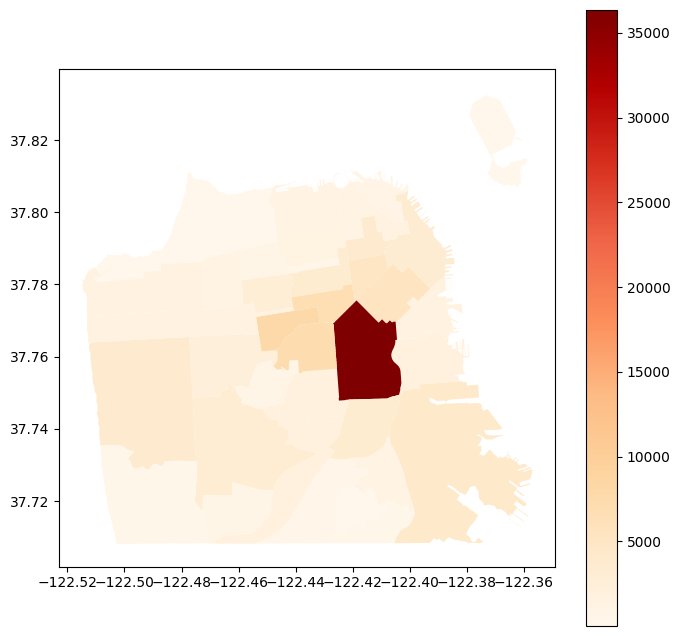

In [17]:
# set figure size
fig, ax = plt.subplots(figsize=(8, 8))

# set up map: specify column, color scheme, etc.
neighborhood_graffiti.plot(
    column="count", 
    cmap="OrRd", # color scheme - see more here https://matplotlib.org/stable/gallery/color/colormap_reference.html
    legend=True,
    linewidth=0.3,
    ax=ax
)

# show map
plt.show()

## Question 2: Which neighborhood has the greatest share of "offensive" graffiti complaints?

Filter data to "offensive" complaints

In [18]:
offensive_complaints = graffiti_with_nhood[graffiti_with_nhood['Request Type'] == 'offensive']

What's the overall share of offensive complaints? 

In [19]:
len(offensive_complaints)/len(graffiti_with_nhood) * 100

13.681307701530715

Let's break it down by neighborhood — first, `groupby()` neighborhood and request type

In [20]:
neighborhood_types = graffiti_with_nhood.groupby(['nhood','Request Type']).size().reset_index(name="count")

Then make a new column showing the share of each complaint type by neighborhood

In [21]:
neighborhood_types['pct'] = (
    neighborhood_types['count'] /
    neighborhood_types.groupby('nhood')['count'].transform('sum')
) * 100

neighborhood_types.head()

,nhood,Request Type,count,pct
0,Bayview Hunters Point,not_offensive,4110,94.613260
1,Bayview Hunters Point,offensive,229,5.271639
2,Bayview Hunters Point,post_abatement_inspection,5,0.115101
3,Bernal Heights,not_offensive,3254,93.452039
4,Bernal Heights,offensive,227,6.519242


Now filter to only offensive complaints

In [22]:
offensive_share = neighborhood_types[neighborhood_types['Request Type'] == 'offensive']

Take a look at the data

In [23]:
offensive_share.sort_values(by='pct',ascending=False)

,nhood,Request Type,count,pct
38,Lincoln Park,offensive,4,33.333333
12,Excelsior,offensive,148,29.133858
78,Potrero Hill,offensive,494,28.521940
99,Twin Peaks,offensive,151,25.593220
43,Marina,offensive,293,23.402556
20,Golden Gate Park,offensive,293,19.150327
40,Lone Mountain/USF,offensive,544,18.915160
94,Tenderloin,offensive,945,18.442623
86,Seacliff,offensive,20,18.181818
46,McLaren Park,offensive,5,17.857143


##### Let's map it!

Merge the data with the geometries with `.merge()`

In [24]:
neighborhood_offensive_pct = neighborhoods.merge(offensive_share, on='nhood', how='left')


Visualize the data using `plot()`

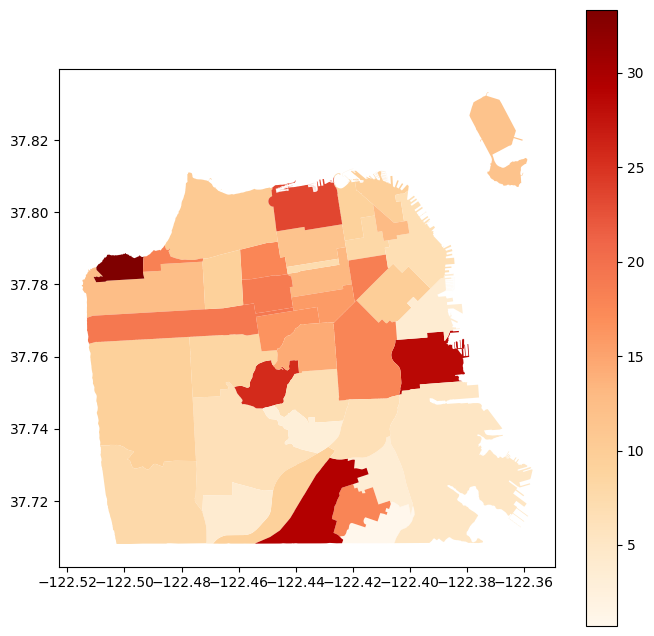

In [25]:
# set figure size
fig, ax = plt.subplots(figsize=(8, 8))

# set up map: specify column, color scheme, etc.
neighborhood_offensive_pct.plot(
    column="pct", 
    cmap="OrRd", # color scheme - see more here https://matplotlib.org/stable/gallery/color/colormap_reference.html
    legend=True,
    linewidth=0.3,
    ax=ax
)

# show map
plt.show()

## Question 3: How many complaints fall within half a mile of a police station? 

##### Switch our CRS to _geometry_ instead of _geography_. 
**Geographic** Coordinate Reference Systems use degrees (lat/long) to locate things on a sphere.
**Projected** Coordinate Reference Systems  use a 2D plane in meters and feet — helpful to measure distances!


We're going to use a local SF projection; adapt to your location as needed.

In [26]:
crs_feet = 'EPSG:7132'

Update the crs for police stations and graffiti data

In [27]:
stations_proj = stations.to_crs(crs_feet)
graffiti_proj = graffiti.to_crs(crs_feet)

##### Create a buffer around the stations and find complaints within it

Add a column with a buffer of 0.5 miles (2640 ft) around each police station using `buffer()`

In [28]:
stations_proj['geometry'] = stations_proj.buffer(2640)

Create a new dataframe using `sjoin()` to find complaints within the station buffer

In [29]:
within_buffers = gpd.sjoin(graffiti_proj, stations_proj[['DISTRICT','geometry']], predicate='within')

Since one point might fall into more than one buffer area, let's drop duplicates (on `CaseID`).

In [30]:
within_buffers = within_buffers.drop_duplicates(subset=['CaseID'])

Check what share of graffiti is near a police station

In [31]:
len(within_buffers) / len(graffiti_proj) * 100

39.621917589225056

##### Visualize the data

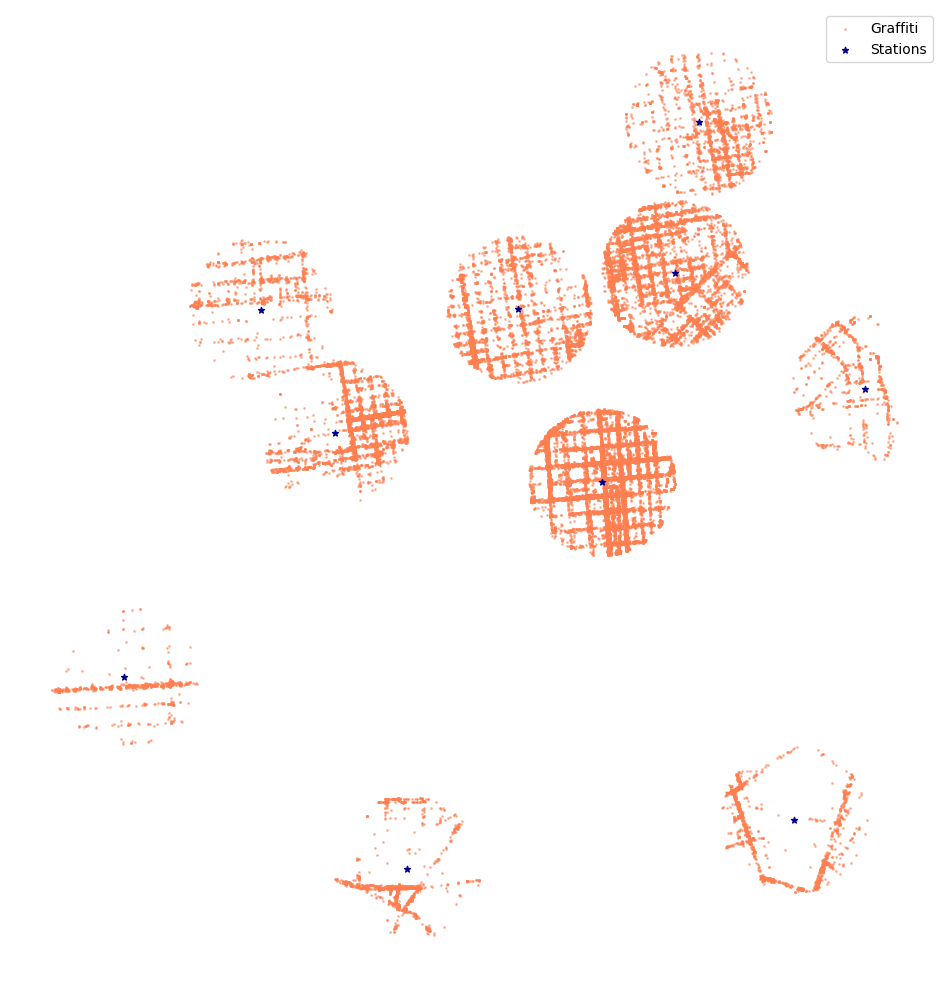

In [32]:
# Define our figure size and axes with `plt.subplots()`
fig, ax = plt.subplots(figsize=(10, 10))

# Plot our graffiti with `.plot()`
within_buffers.plot(ax=ax, color='coral', markersize=1, alpha=0.5, label='Graffiti')

# Plot our stations with `.plot()` - don't forget to change the CRS! 
stations.to_crs(crs_feet).plot(ax=ax, color='darkblue', markersize=20, marker="*", label='Stations')

# Optional parameters for legend; layout        
ax.legend()
ax.axis('off')
plt.tight_layout()

# Show our map with `plt.show()`!
plt.show()

## Question 4: Which police station has the most graffiti nearby? 

Use `groupby` to count complaints by district

In [33]:
near_police_hq = within_buffers.groupby('DISTRICT').size().sort_values(ascending=False).reset_index(name="count")

Sort and look at the data

In [34]:
near_police_hq.sort_values(by='count',ascending=False)

,DISTRICT,count
0,MISSION,21738
1,TENDERLOIN,8290
2,PARK,5946
3,NORTHERN,4271
4,CENTRAL,2713
5,INGLESIDE,1759
6,BAYVIEW,1753
7,RICHMOND,1209
8,SOUTHERN,1010
9,TARAVAL,880


Add percentages column

In [35]:
near_police_hq['pct'] = near_police_hq['count'] / len(within_buffers) * 100

In [36]:
near_police_hq

,DISTRICT,count,pct
0,MISSION,21738,43.854022
1,TENDERLOIN,8290,16.724162
2,PARK,5946,11.995400
3,NORTHERN,4271,8.616272
4,CENTRAL,2713,5.473179
5,INGLESIDE,1759,3.548589
6,BAYVIEW,1753,3.536484
7,RICHMOND,1209,2.439024
8,SOUTHERN,1010,2.037564
9,TARAVAL,880,1.775303


At the end of the class, please shut down your terminal with `Ctrl + C`.